# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 11 </span>
## <span style="color:orange"> Keras - Neural Network regression </span>

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make prediction, we will consider a NN that depend on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Setting up a seed and importing libraries ###

In [1]:
import os
from datetime import datetime
import random
import math
import numpy as np
import matplotlib.pyplot as plt


import tensorflow as tf
print(tf.__version__)
from tensorflow import keras
from tensorflow.keras import layers, optimizers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.initializers import GlorotUniform

# 1. Set Python built-in random seed
random.seed(0)

# 2. Set NumPy random seed
np.random.seed(0)

# 3. Set TensorFlow random seed
tf.random.set_seed(0)

2.18.1


### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

Let's start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

In [2]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Now let's generate a set of input data which will slightly deviate from our ideal behaviour using a random noise (that actually is set to zero):

In [3]:
# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 100)
x_valid = np.random.uniform(-1, 1, 10)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.0 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

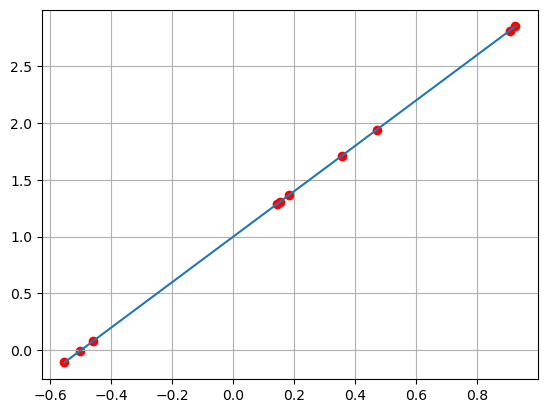

In [4]:
# plot training and target dataset
plt.plot(x_valid, y_target)
plt.scatter(x_valid, y_valid, color='r')
plt.grid(True); plt.show()

If you remember how a single node of a neural network works, you can easily spot that **just a single neuron can make the job**. So let's start using a simple Sequential model with just one layer on one neuron only!

In [5]:
# compose the NN model

model = Sequential([
    Input(shape=(1,)),
    Dense(1)         
])

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [6]:
# get a summary of our composed model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [7]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid),
          verbose = 0
                   )

In [8]:
# return weights
model.get_weights()

[array([[1.1453648]], dtype=float32), array([0.9793382], dtype=float32)]

In [9]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2158 - mse: 0.2158

Test loss: 0.21584287285804749
Test accuracy: 0.21584287285804749


In [10]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2158 - mse: 0.2158

Test loss: 0.21584287285804749
Test accuracy: 0.21584287285804749


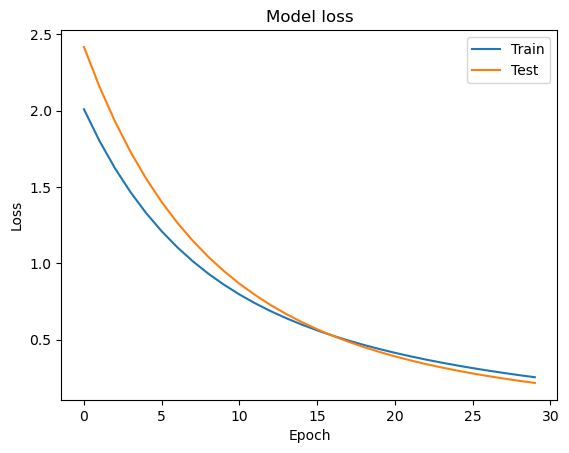

In [11]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


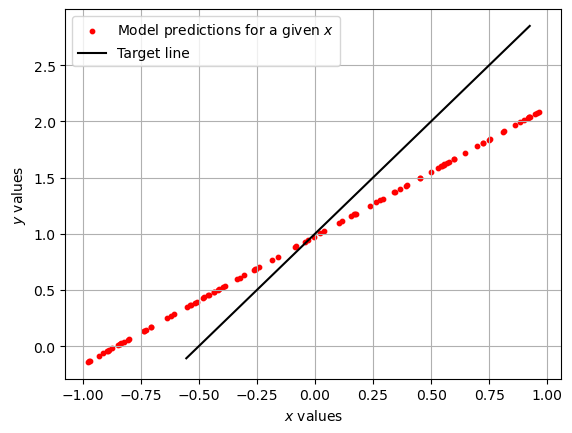

In [12]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r', s=10)
plt.plot(x_valid, y_target, color='black')
plt.ylabel('$y$ values')
plt.xlabel('$x$ values')
plt.legend(['Model predictions for a given $x$', 'Target line'], loc='best')
plt.grid(True)
plt.show()

# Exercise 11.1

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.

## Solution ##
-----------

Let's see how our perceptron performs with the following parameters:

- $N_{epochs} = \{10, 30,100\}$
- $N_{train} = \{32,100,200\}$
- $\sigma = \{0.0, 0.2, 0.4\}$

We will consider the setting $(N_{epochs} = 30 ,N_{train} = 100, \sigma = 0.0)$ to be the "reference" setting. So we will set these values fixed while varying one of the three values. This is to avoid making too many combinations (there are 81 combinations in total).

In [13]:
# Defining our perceptron
perceptron_model = Sequential([
    Input(shape=(1,)),
    Dense(1)         
])

# compile the model choosing optimizer, loss and metrics objects
perceptron_model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

# get a summary of our composed model
perceptron_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

<u>Note</u>: the two (trainable) parameters refer to the **weight** and **bias** of the single neuron.

## 1.1) Varying the input size $N_{train}$ ##
--------

- $N_{Epochs} = 30$
- $\sigma = 0.0$

In [14]:
# ==== Getting the input, test and validation data ready ====
np.random.seed(0)

a = 2
b = 1.4

x_train_datasets = [
    np.random.uniform(-1, 1, 32),
    np.random.uniform(-1, 1, 100),
    np.random.uniform(-1, 1, 200),
    np.random.uniform(-1, 1, 400)
]

x_valid_datasets = [
    np.random.uniform(-1, 1, 3),
    np.random.uniform(-1, 1, 10),
    np.random.uniform(-1, 1, 20),
    np.random.uniform(-1, 1, 40)
]

for arr in x_valid_datasets:
    arr.sort()

y_target_datasets = [a * x + b for x in x_valid_datasets]  # ideal (target) linear function

In [15]:
y_train_datasets = []
y_valid_datasets = []
sigma = 0.0

y_train_datasets = [np.random.normal(a * x + b, sigma) for x in x_train_datasets]
y_valid_datasets = [np.random.normal(a * x + b, sigma) for x in x_valid_datasets]

In [16]:
histories = []
scores = []
scores_exact = []

models = []

for i, (x_train, y_train, x_valid, y_valid, y_target) in enumerate(
    zip(x_train_datasets, y_train_datasets, x_valid_datasets, y_valid_datasets, y_target_datasets), start=1
):
    print(f"\n=== Training on dataset {i} ===")
    print(f"Training dataset size: {len(x_train)}, Validation dataset size: {len(x_valid)}")

    # Creating a new model at each iteration. Important, otherwise the weights carry over!
    # Note: explicit weights and biases initialization to guarantee reproducibility
    perceptron_model = Sequential([
        Input(shape=(1,)),
        Dense(1,
        kernel_initializer=GlorotUniform(seed=0),
        bias_initializer='zeros')
    ])
    perceptron_model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    # Training the perceptron
    history = perceptron_model.fit(
        x=x_train, y=y_train,
        batch_size=32, epochs=30,
        shuffle=True,
        validation_data=(x_valid, y_valid),
        verbose=0  # suppressing detailed output
    )

    # 3. Evaluate
    score = perceptron_model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
    print(f"Validation loss: {score[0]:.4f}, MSE: {score[1]:.4f}")

    histories.append(history)
    scores.append(score)
    models.append(perceptron_model)


=== Training on dataset 1 ===
Training dataset size: 32, Validation dataset size: 3
Validation loss: 0.2088, MSE: 0.2088

=== Training on dataset 2 ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 1.0256, MSE: 1.0256

=== Training on dataset 3 ===
Training dataset size: 200, Validation dataset size: 20
Validation loss: 0.1729, MSE: 0.1729

=== Training on dataset 4 ===
Training dataset size: 400, Validation dataset size: 40
Validation loss: 0.0152, MSE: 0.0152


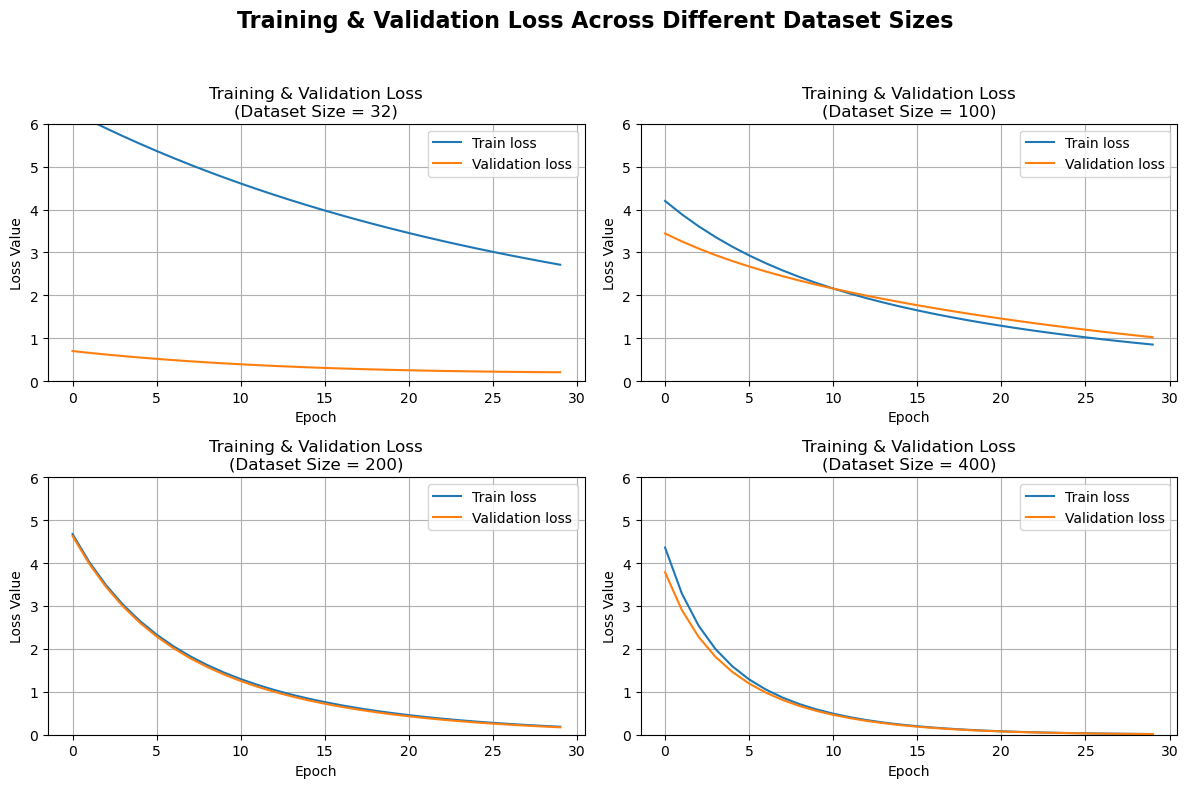

In [17]:
os.makedirs("./Figures", exist_ok=True)

n_plots = len(histories)

fig, axes = plt.subplots(math.ceil(n_plots/2), 2, figsize=(12, 4*math.ceil(n_plots/2)))

axes = axes.flatten()

for i, (history, x_train, ax) in enumerate(zip(histories, x_train_datasets, axes), start=1):
    dataset_size = len(x_train)

    ax.plot(history.history['loss'], label='Train loss')
    ax.plot(history.history['val_loss'], label='Validation loss')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss Value')
    ax.set_title(f'Training & Validation Loss\n(Dataset Size = {dataset_size})')
    ax.legend()
    ax.grid(True)

    ax.set_ylim([0, 6.0])

    save_path = f'./Figures/loss_plot_dataset{i}.png'
    fig_individual, ax_individual = plt.subplots(figsize=(6, 5))
    ax_individual.plot(history.history['loss'], label='Train loss')
    ax_individual.plot(history.history['val_loss'], label='Validation loss')
    ax_individual.set_xlabel('Epoch')
    ax_individual.set_ylabel('Loss Value')
    ax_individual.set_title(f'Training & Validation Loss (Dataset Size = {dataset_size})')
    ax_individual.legend()
    ax_individual.grid(True)
    fig_individual.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig_individual)

for j in range(i, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Training & Validation Loss Across Different Dataset Sizes", fontsize=16, weight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

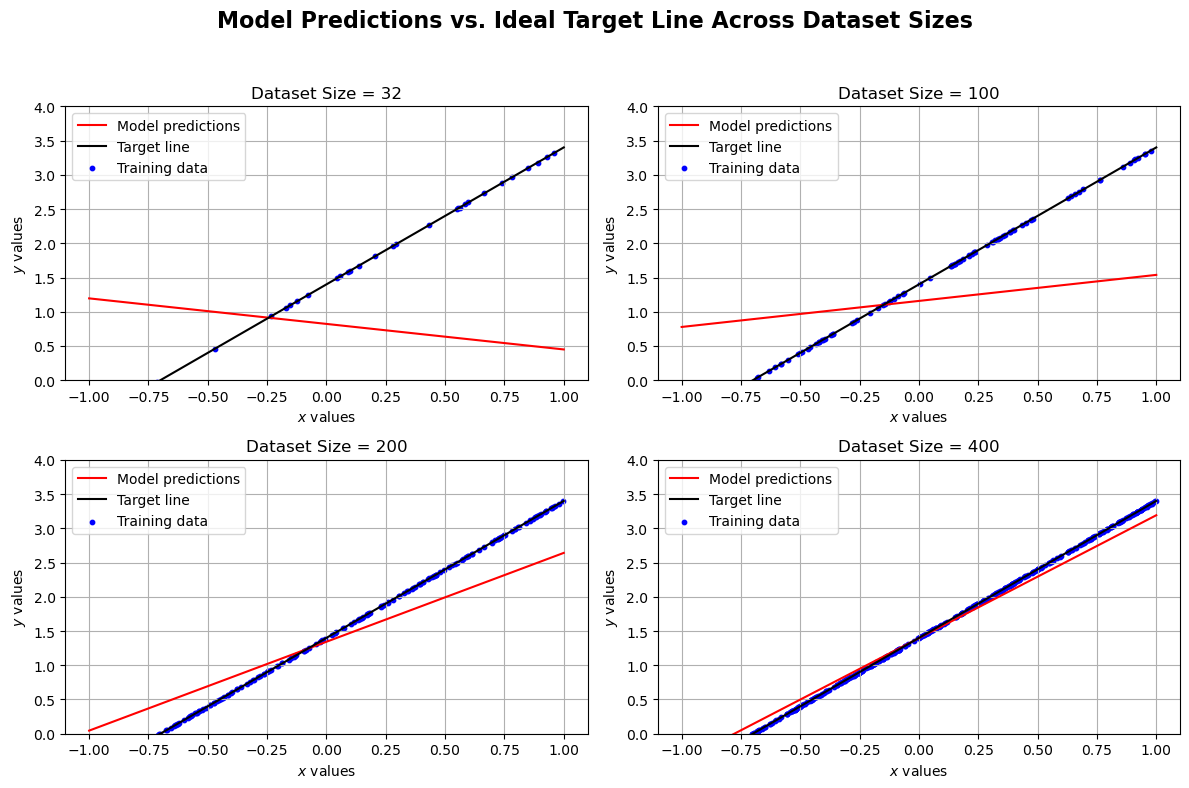

In [18]:
x_predicted = tf.convert_to_tensor(np.linspace(-1, 1, 100).reshape(-1, 1), dtype=tf.float32)
y_target_predicted = a * x_predicted + b  # Ideal target line

y_predictions = [model(x_predicted, training=False).numpy() for model in models]

fig, axes = plt.subplots(math.ceil(len(models)/2), 2, figsize=(12, 4*math.ceil(len(models)/2)))
axes = axes.flatten()

for i, (x_train, y_train, y_predicted, x_valid, y_target, ax) in enumerate(
    zip(x_train_datasets, y_train_datasets, y_predictions, x_valid_datasets, y_target_datasets, axes), start=1
):
    dataset_size = len(x_train_datasets[i-1])

    ax.plot(x_predicted, y_predicted, color='r', label='Model predictions')
    ax.plot(x_predicted, y_target_predicted, color='black', label='Target line')
    ax.scatter(x_train, y_train, color='blue', label='Training data', s=10)
    ax.set_xlabel('$x$ values')
    ax.set_ylabel('$y$ values')
    ax.set_ylim([0, 4.0])
    ax.set_title(f'Dataset Size = {dataset_size}')
    ax.legend(loc='best')
    ax.grid(True)

    save_path = f'./Figures/prediction_dataset{i}.png'
    fig_individual, ax_individual = plt.subplots(figsize=(6, 5))
    ax_individual.plot(x_predicted, y_predicted, color='r', label='Model predictions')
    ax_individual.plot(x_predicted, y_target_predicted, color='black', label='Target line')
    ax_individual.set_xlabel('$x$ values')
    ax_individual.set_ylabel('$y$ values')
    ax_individual.set_ylim([0, 4.0])
    ax_individual.set_title(f'Model Predictions (Dataset Size = {dataset_size})')
    ax_individual.legend(loc='best')
    ax_individual.grid(True)
    fig_individual.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig_individual)

for j in range(i, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Model Predictions vs. Ideal Target Line Across Dataset Sizes", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Observations ##
--------

### Learning perfomance ###

The first thing we see upon inspecting the plots is the decay of the loss values getting more pronounced as we increase the size of the training dataset (by extension also the validation dataset since the latter is 10% the size of the former). This indicates that the NN learns "faster" (i.e. converges more easily) with a larger dataset.

The second thing to notice is the relative position between the training and validation loss curves depending on the training datasets size. In most of the cases we can see that the training loss curve lies above the validation loss. This feature is preferable and can be understood intuitively: at first the neural network's parameters are not yet optimized, and so it "struggles" produce accurate outputs at first. Wheras the outputs produced after training should naturally be more accurate and lead to a reduced loss value.

1. Dataset size = 32

   In this case we can see that the training loss curve lies well above the validation loss. This could be due to the validation set being very small and therefore lacking some degree of variation within the set, making evaluation easy and the validation loss artificially low. An important gap between the training and validation loss values usually indicates that validation dataset isn't fully representative of the training dataset. In our case it suggests that we should increase the size of our training dataset.

2. Dataset size = 100

   In this plot we can see a point at which the validation loss value goes above the training loss value. This could be understood as the model performing slightly worse on unseen data. If the gap becomes important and it happens at some "inversion point" it could be a sign of overfitting.


3. Dataset sizes 200 and 400

   The behavior of the two curves being very close to one another with the training loss being slightly above the validation loss is a sign that the model is trained accurately, as the unseen data produces almost identical performance as in training. We can therefore conclude that in this particular setting increasing the training dataset size improves the model's performance.



### Predicting performance ###

## 1.2) Varying the number of epochs $N_{epoch}$ ##
--------

- $N_{training} = 100$
- $\sigma = 0.0$

In [19]:
histories = []
scores = []
models_epoch = []  # store models trained at each epoch

epochs = [15, 30, 60, 120]

x_train = x_train_datasets[1]
y_train = y_train_datasets[1]
x_valid = x_valid_datasets[1]
y_valid = y_valid_datasets[1]

for epoch in epochs:
    print(f"\n=== Training with {epoch} epochs ===")
    print(f"Training dataset size: {len(x_train)}, Validation dataset size: {len(x_valid)}")

    # Creating a new model at each iteration. Important, otherwise the weights carry over!
    # Note: explicit weights and biases initialization to guarantee reproducibility
    perceptron_model = Sequential([
        Input(shape=(1,)),
        Dense(1,
        kernel_initializer=GlorotUniform(seed=0),
        bias_initializer='zeros')         
    ])
    perceptron_model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    # Training the perceptron
    history = perceptron_model.fit(
        x=x_train, y=y_train,
        batch_size=32, epochs=epoch,
        shuffle=True,
        validation_data=(x_valid, y_valid),
        verbose=0  # suppressing detailed output
    )

    # 3. Evaluate
    score = perceptron_model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
    print(f"Validation loss: {score[0]:.4f}, MSE: {score[1]:.4f}")

    histories.append(history)
    models_epoch.append(perceptron_model)


=== Training with 15 epochs ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 1.8417, MSE: 1.8417

=== Training with 30 epochs ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 1.0256, MSE: 1.0256

=== Training with 60 epochs ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 0.2976, MSE: 0.2976

=== Training with 120 epochs ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 0.0229, MSE: 0.0229


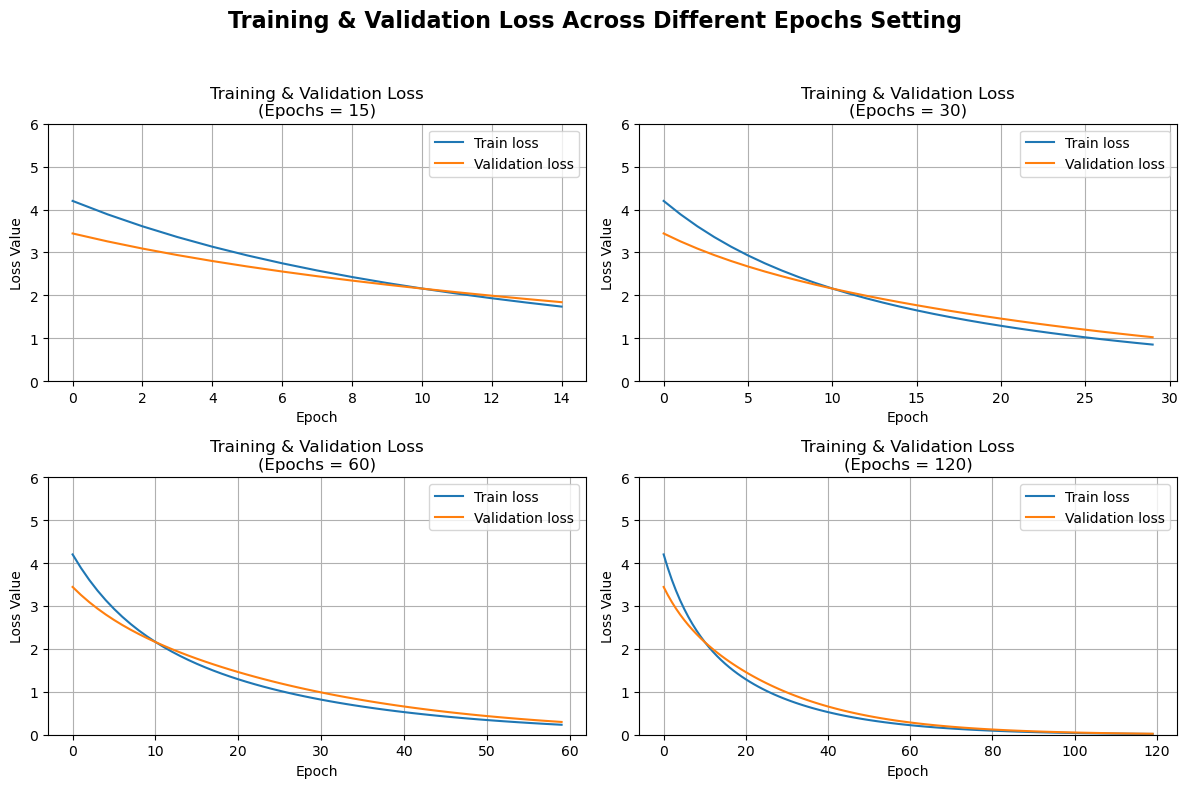

In [20]:
os.makedirs("./Figures", exist_ok=True)

n_plots = len(histories)
fig, axes = plt.subplots(math.ceil(n_plots/2), 2, figsize=(12, 4*math.ceil(n_plots/2)))
axes = axes.flatten()

for i, (history, x_train_values, ax, epoch) in enumerate(zip(histories, x_train, axes, epochs), start=1):
    
    ax.plot(history.history['loss'], label='Train loss')
    ax.plot(history.history['val_loss'], label='Validation loss')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss Value')
    ax.set_title(f'Training & Validation Loss\n(Epochs = {epoch})')
    ax.legend()
    ax.grid(True)

    ax.set_ylim([0, 6.0])

    save_path = f'./Figures/loss_plot_{epoch}_epochs.png'
    fig_individual, ax_individual = plt.subplots(figsize=(6, 5))
    ax_individual.plot(history.history['loss'], label='Train loss')
    ax_individual.plot(history.history['val_loss'], label='Validation loss')
    ax_individual.set_xlabel('Epoch')
    ax_individual.set_ylabel('Loss Value')
    ax_individual.set_title(f'Training & Validation Loss (Epochs = {epoch})')
    ax_individual.legend()
    ax_individual.grid(True)
    fig_individual.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig_individual)

for j in range(i, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Training & Validation Loss Across Different Epochs Setting", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

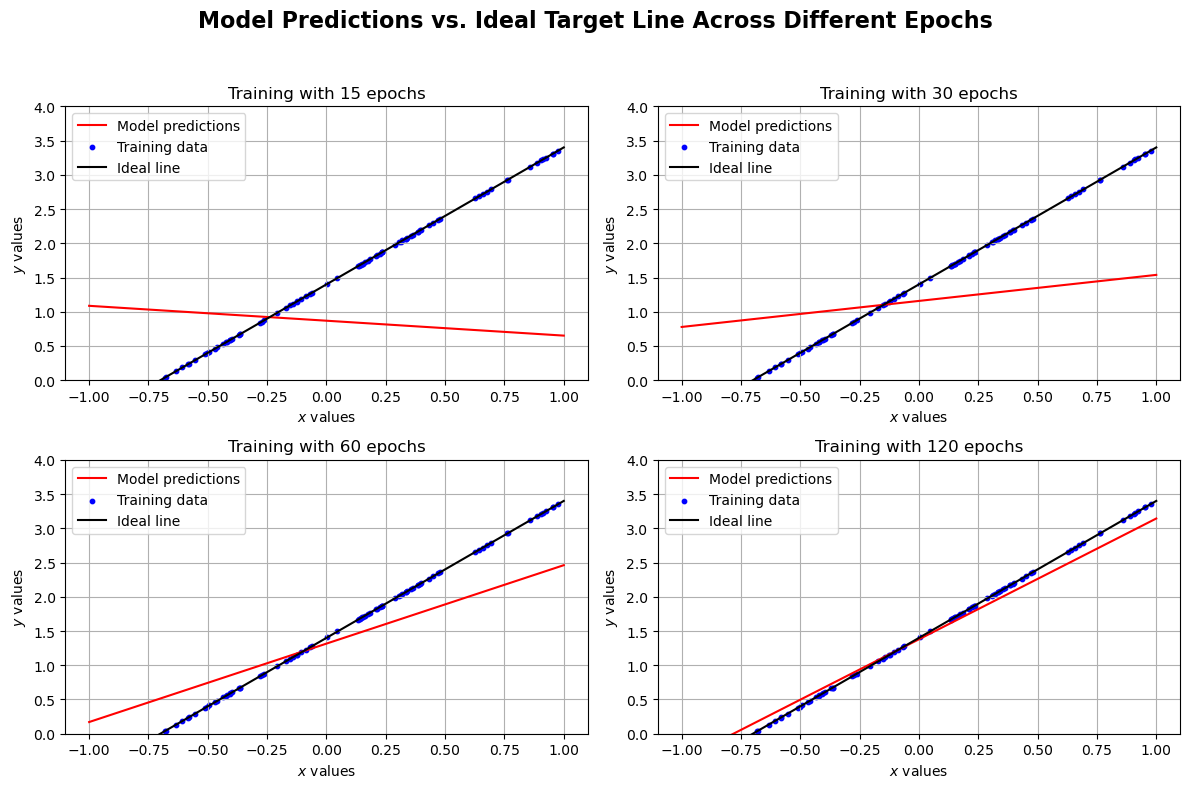

In [21]:
x_predicted = tf.convert_to_tensor(np.linspace(-1, 1, 100).reshape(-1, 1), dtype=tf.float32)
y_target_predicted = a * x_predicted + b  # Ideal target line

y_predictions = [model(x_predicted, training=False).numpy() for model in models_epoch]

fig, axes = plt.subplots(math.ceil(len(models_epoch)/2), 2, figsize=(12, 4*math.ceil(len(models_epoch)/2)))
axes = axes.flatten()

for i, (y_predicted, epoch, ax) in enumerate(zip(y_predictions, epochs, axes), start=1):
    
    # Plot model predictions and ideal target line
    ax.plot(x_predicted, y_predicted, color='r', label='Model predictions')
    ax.scatter(x_train, y_train, color='blue', label='Training data', s=10)
    ax.plot(x_predicted, y_target_predicted, color='black', label='Ideal line')
    ax.set_xlabel('$x$ values')
    ax.set_ylabel('$y$ values')
    ax.set_ylim([0, 4.0])
    ax.set_title(f'Training with {epoch} epochs')
    ax.legend(loc='best')
    ax.grid(True)

    # Save individual figure
    save_path = f'./Figures/prediction_epochs_{epoch}.png'
    fig_individual, ax_individual = plt.subplots(figsize=(6, 5))
    ax_individual.plot(x_predicted, y_predicted, color='r', label='Model predictions')
    ax_individual.plot(x_predicted, y_target_predicted, color='black', label='Ideal line')
    ax_individual.set_xlabel('$x$ values')
    ax_individual.set_ylabel('$y$ values')
    ax_individual.set_ylim([0, 4.0])
    ax_individual.set_title(f'Model Predictions (Epochs = {epoch})')
    ax_individual.legend(loc='best')
    ax_individual.grid(True)
    fig_individual.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig_individual)

for j in range(i, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Model Predictions vs. Ideal Target Line Across Different Epochs", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Observations ###

Globally we can observe the same trends as when we varied the training dataset size. We can notice that we get the same behaviour (as expected) with the setting $N_{dataset}= 100$ and $N_{epochs}$ as in the previous experiment.

One relevant feature that could be highlighted is the tendency across all cases to make the validation loss value greater than the training loss value as we increase the number of epochs, and note that this inversion happen at the 10th epoch.

We could interpret this as concluding that training with 100 examples for more than 10 epochs results in overfitting. But interestingly enough we can also note that with a very large number of epochs (circa 100) the two curves start to get closer again.

## 1.3) Varying the noise $\sigma$ ##
--------

- $N_{training} = 100$
- $N_{epochs} = 30$


=== Training with sigma = 0.0 ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 1.0256, MSE: 1.0256

=== Training with sigma = 0.1 ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 1.1231, MSE: 1.1231

=== Training with sigma = 0.2 ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 0.9776, MSE: 0.9776

=== Training with sigma = 0.4 ===
Training dataset size: 100, Validation dataset size: 10
Validation loss: 1.1101, MSE: 1.1101


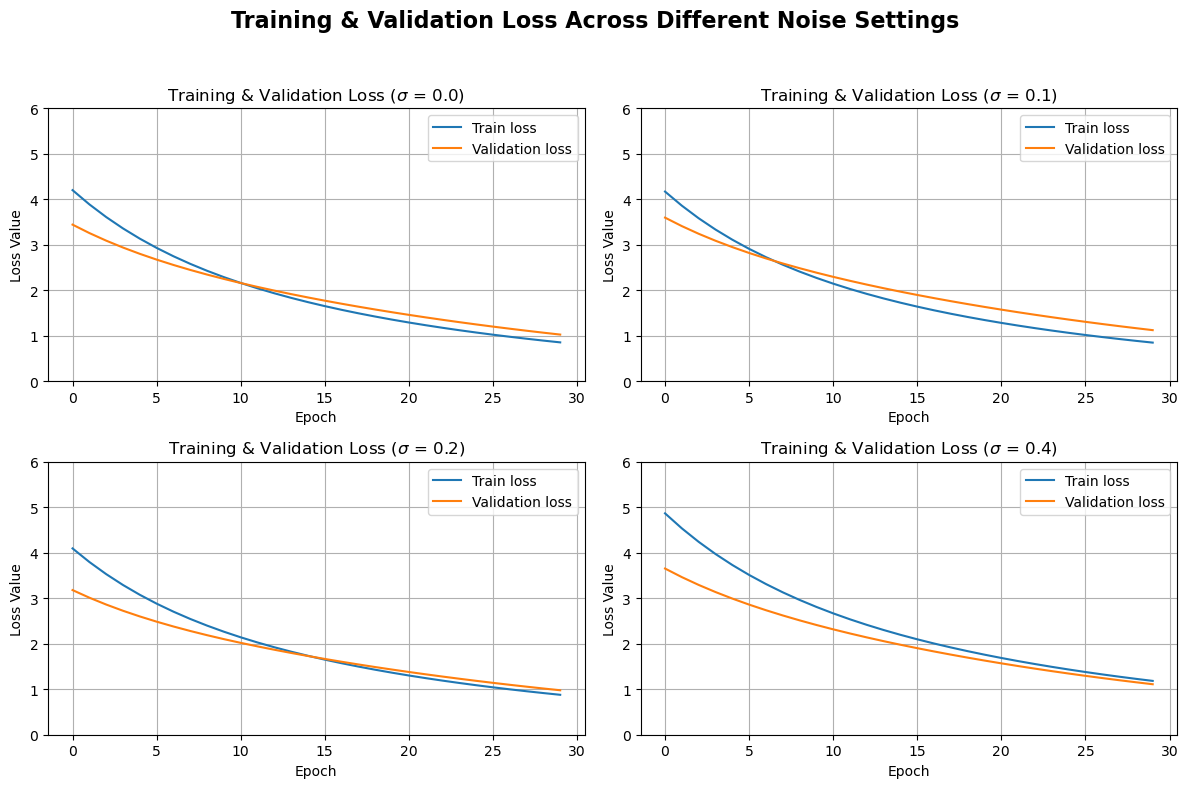

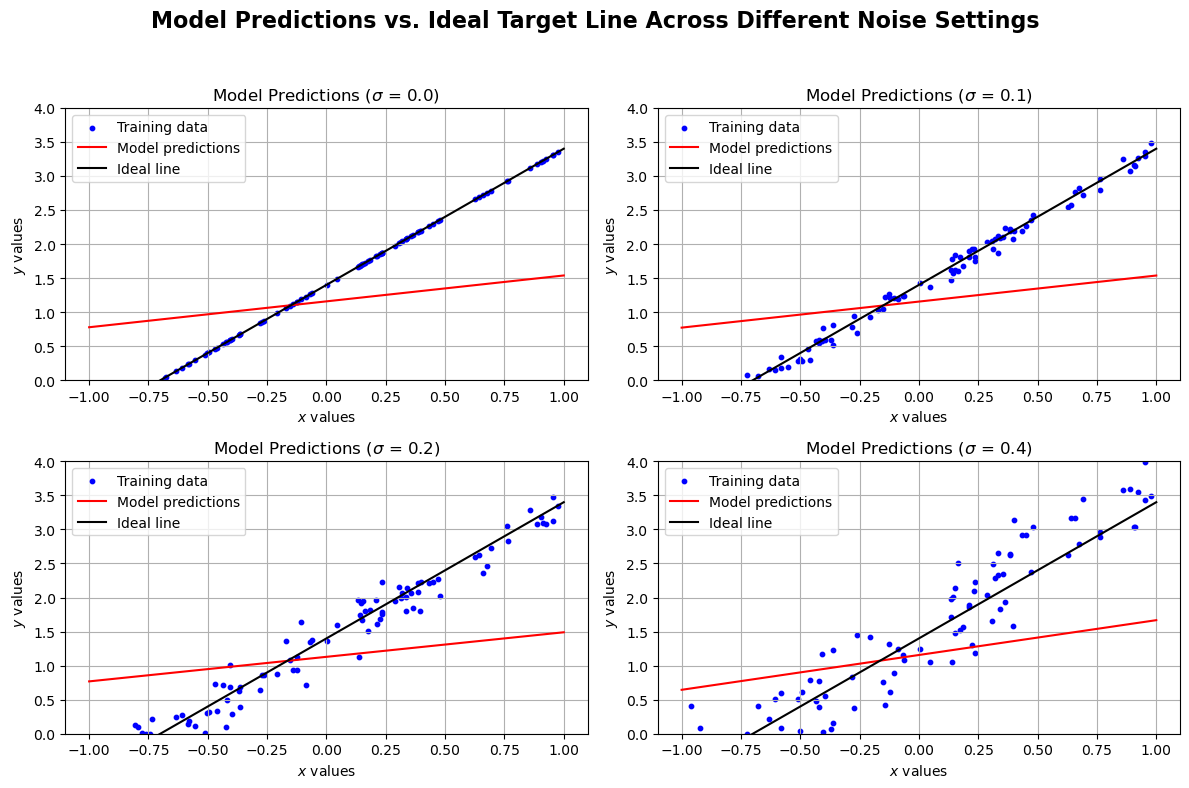

In [22]:
# === Imports ===
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.initializers import GlorotUniform

# === Parameters ===
sigma_values = [0.0, 0.1, 0.2, 0.4]

# Get base datasets
x_train = x_train_datasets[1]
y_train = y_train_datasets[1]

x_valid = x_valid_datasets[1]

histories = []
scores = []
models_sigma = []

y_train_sigma = []

# === Training loop for each sigma ===
for i, sigma in enumerate(sigma_values):
    print(f"\n=== Training with sigma = {sigma} ===")
    print(f"Training dataset size: {len(x_train)}, Validation dataset size: {len(x_valid)}")

    # Generate noisy datasets inside loop (different per sigma)
    rng = np.random.default_rng(seed=123 + i)  # reproducible but different
    y_tr = rng.normal(a * x_train + b, sigma)
    y_val = rng.normal(a * x_valid + b, sigma)

    # New model for each sigma
    perceptron_model = Sequential([
        Input(shape=(1,)),
        Dense(1,
              kernel_initializer=GlorotUniform(seed=0),
              bias_initializer='zeros')
    ])
    perceptron_model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    # Train
    history = perceptron_model.fit(
        x=x_train, y=y_tr,
        batch_size=32, epochs=30,
        shuffle=True,
        validation_data=(x_valid, y_val),
        verbose=0
    )

    # Evaluate
    score = perceptron_model.evaluate(x_valid, y_val, batch_size=32, verbose=0)
    print(f"Validation loss: {score[0]:.4f}, MSE: {score[1]:.4f}")

    histories.append(history)
    scores.append(score)
    models_sigma.append(perceptron_model)
    y_train_sigma.append(y_tr)
    

# === Plot Training & Validation Losses ===
os.makedirs("./Figures", exist_ok=True)

n_plots = len(histories)
fig, axes = plt.subplots(math.ceil(n_plots / 2), 2, figsize=(12, 4 * math.ceil(n_plots / 2)))
axes = axes.flatten()

for i, (history, sigma, ax) in enumerate(zip(histories, sigma_values, axes), start=1):
    ax.plot(history.history['loss'], label='Train loss')
    ax.plot(history.history['val_loss'], label='Validation loss')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss Value')
    ax.set_title(rf'Training & Validation Loss ($\sigma$ = {sigma})')
    ax.legend()
    ax.grid(True)
    ax.set_ylim([0, 6.0])  # fixed scale

    # Save individual loss plot
    save_path = f'./Figures/loss_plot_sigma{sigma}.png'
    fig_individual, ax_individual = plt.subplots(figsize=(6, 5))
    ax_individual.plot(history.history['loss'], label='Train loss')
    ax_individual.plot(history.history['val_loss'], label='Validation loss')
    ax_individual.set_xlabel('Epoch')
    ax_individual.set_ylabel('Loss Value')
    ax_individual.set_title(rf'Training & Validation Loss ($\sigma$ = {sigma})')
    ax_individual.legend()
    ax_individual.grid(True)
    ax_individual.set_ylim([0, 6.0])
    fig_individual.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig_individual)

# Hide unused axes
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Training & Validation Loss Across Different Noise Settings", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === Plot Model Predictions ===
x_predicted = tf.convert_to_tensor(np.linspace(-1, 1, 100).reshape(-1, 1), dtype=tf.float32)
y_target_predicted = a * x_predicted + b  # Ideal target line

y_predictions_sigma = [model(x_predicted, training=False).numpy() for model in models_sigma]

fig, axes = plt.subplots(math.ceil(len(models_sigma) / 2), 2, figsize=(12, 4 * math.ceil(len(models_sigma) / 2)))
axes = axes.flatten()

for i, (y_train, y_predicted, sigma, ax) in enumerate(zip(y_train_sigma, y_predictions_sigma, sigma_values, axes), start=1):
    ax.scatter(x_train, y_train, color='blue', label='Training data', s=10)
    ax.plot(x_predicted, y_predicted, color='r', label='Model predictions')
    ax.plot(x_predicted, y_target_predicted, color='black', label='Ideal line')
    ax.set_xlabel('$x$ values')
    ax.set_ylabel('$y$ values')
    ax.set_ylim([0, 4.0])
    ax.set_title(rf'Model Predictions ($\sigma$ = {sigma})')
    ax.legend(loc='best')
    ax.grid(True)

    # Save each prediction plot
    save_path = f'./Figures/prediction_sigma_{sigma}.png'
    fig_individual, ax_individual = plt.subplots(figsize=(6, 5))
    ax_individual.plot(x_predicted, y_predicted, color='r', label='Model predictions')
    ax_individual.plot(x_predicted, y_target_predicted, color='black', label='Ideal line')
    ax_individual.set_xlabel('$x$ values')
    ax_individual.set_ylabel('$y$ values')
    ax_individual.set_ylim([0, 4.0])
    ax_individual.set_title(rf'Model Predictions ($\sigma$ = {sigma})')
    ax_individual.legend(loc='best')
    ax_individual.grid(True)
    fig_individual.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig_individual)

# Hide unused axes
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Model Predictions vs. Ideal Target Line Across Different Noise Settings", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Observations ##
--------

### Learning perfomance ###

### Predicting performance ###

We can notice the red line representing the predicted $y$ values are almost identical throughout all plots. This is due to the model's reprensentational power being too small. And so the learned parameters are almost identical in all cases.

# Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

In order to make practice with NN, explore reasonable different choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Make graphs comparing fits for different NNs.
Check your NN models by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

## Solution ##
-----------

### Data Generation ###

Let us start by first regenerating our random training data:

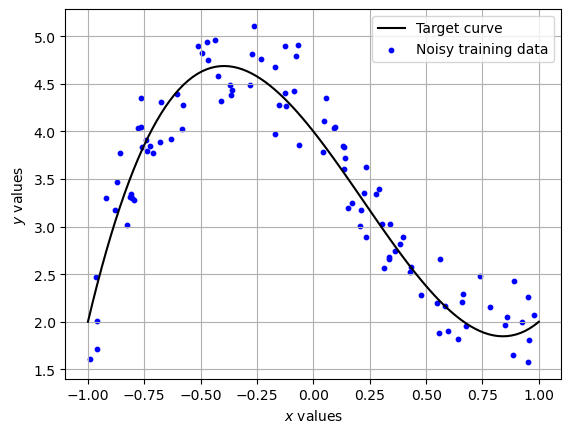

In [23]:
# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 100)
x_valid = np.random.uniform(-1, 1, 10)
x_valid.sort()

x_plot = np.linspace(-1, 1, 100)
y_target = 4 - 3 * x_plot - 2 * x_plot * x_plot + 3* pow(x_plot, 3) # ideal (target) polynomial function

sigma = 0.3 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(4 - 3 * x_train - 2 * x_train * x_train + 3* pow(x_train, 3), sigma)
y_valid = np.random.normal(4 - 3 * x_valid - 2 * x_valid * x_valid + 3* pow(x_valid, 3), sigma)

plt.plot(x_plot, y_target, color='black')
plt.scatter(x_train, y_train, color='blue', s=10)
plt.ylabel('$y$ values')
plt.xlabel('$x$ values')
plt.legend(['Target curve', 'Noisy training data'], loc='best')
plt.grid(True)
plt.show()

### Model Setting 0: simple perceptron ###
-----------
Let us see how our simple perceceptron performs while attempting to fit this polynomial curve. We will use the following setting:

| Layer Type   | Number of Neurons | Activation |
|-------------|-----------------|--------------|
| Input Layer | 1               | Linear       |
| Output Layer| 1               | Linear       |

- Optimizer: Stochastic Gradient Descent
- Loss function: Mean Squared Error
- Epochs: 30
- Batch size: 32

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


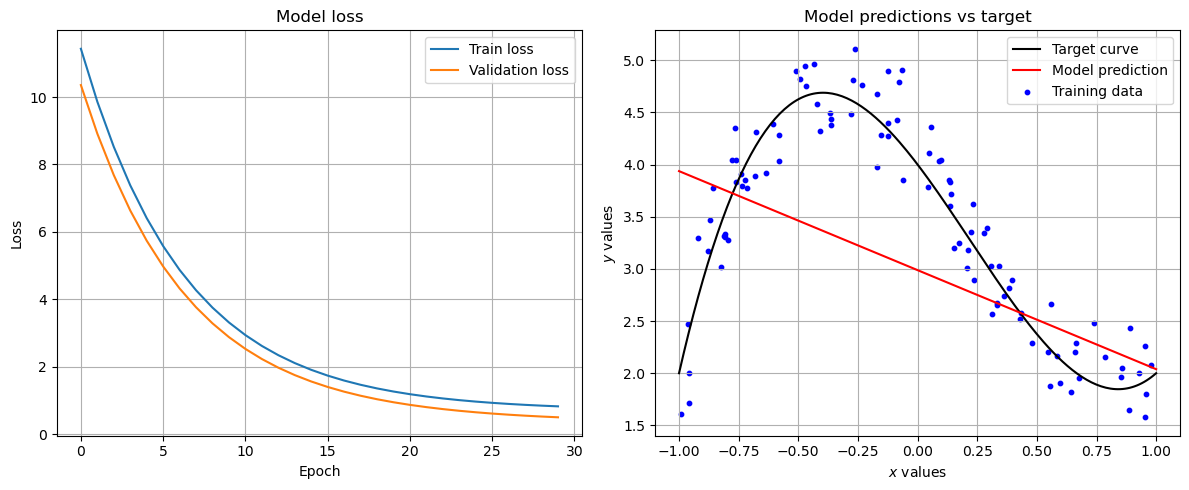

In [24]:
model = Sequential([
    Input(shape=(1,)),
    Dense(1,
            kernel_initializer=GlorotUniform(seed=0),
            bias_initializer='zeros',
            activation='linear')
    ])

model.compile(optimizer='sgd', loss='mse', metrics=['mse'])
history1 = model.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=30,
    verbose=0,
    validation_data=(x_valid, y_valid),
    shuffle=True,
)

# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)

# Predictions for plotting
x_plot = np.linspace(-1, 1, 200).reshape(-1, 1)
y_target = 4 - 3*x_plot - 2*x_plot**2 + 3*x_plot**3
y_pred = model.predict(x_plot)

# === Subplots ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) Training & validation loss
axes[0].plot(history1.history['loss'], label='Train loss')
axes[0].plot(history1.history['val_loss'], label='Validation loss')
axes[0].set_title('Model loss')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='best')
axes[0].grid(True)

# (2) Predictions vs. target & training data
axes[1].plot(x_plot, y_target, color='black', label='Target curve')
axes[1].plot(x_plot, y_pred, color='red', label='Model prediction')
axes[1].scatter(x_train, y_train, color='blue', s=10, label='Training data')
axes[1].set_title('Model predictions vs target')
axes[1].set_xlabel('$x$ values')
axes[1].set_ylabel('$y$ values')
axes[1].legend(loc='best')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Observations ##

### Learning Performance ###

As far as the learning performance is concerned it seems like the model's parameters correctly converge towards an optimum. Both the training and validation loss values follow the same trend, the training loss values being slightly greater than the validation loss as discussed previously.

### Predicting Performance ###

Although the model correctly finds an optimum, this doesn't necessarily translates with the neural network making accurate predicitons. As we can see in the plot, our simple perceptron was not able to capture the more complex form of the polynomial curve, and it also only limited to output a line. It is interesting to observe nontheless that it was still able to get the overall "trend" of the training dataset.

### Model Setting 1: simple neural network ###
--------

For the sake of the exercise we are supposing we do not know the formula for the target curve ahead. Instead, we are taking an educated guess and suppose a good fit for this data would be a polynomial of degree 3.

To better capture the underlying structure of the input data we set the size of the input layer to 4 neurons. In this setting, each neuron represent a "feature" or "dimension" of the input data as $[x^0, x^1, x^2, x^3]$.

Following the same logic, the output layer should have a single neuron, to represent the single $y$-value of the output. The size of the hidden layer is somewhat arbitrary at this stage, and it could be interesting to twich it later to see the results. For now, we will not have a hidden layer. The rest of the hyperparameters (optimizer, loss function, etc.) are left as before. 

| Layer Type   | Number of Neurons | Activation |
|-------------|-----------------|--------------|
| Input Layer | 4             | Linear       |
| Output Layer| 1              | Linear       |

- Optimizer: Stochastic Gradient Descent
- Loss function: Mean Squared Error
- Epochs: 30
- Batch size:

### Note: formatting the input: Polynomial Feature Matrix (Degree 3)


For the training set with \(n\) samples, the polynomial feature matrix up to degree 3 is:

$$
X_\text{poly} =
\begin{bmatrix}
1 & x_1 & x_1^2 & x_1^3 \\
1 & x_2 & x_2^2 & x_2^3 \\
1 & x_3 & x_3^2 & x_3^3 \\
\vdots & \vdots & \vdots & \vdots \\
1 & x_{n} & x_{n}^2 & x_{n}^3
\end{bmatrix}
$$

where:
- \(n\) = number of training samples  

This allows us to fit a cubic polynomial of the form:

$$
y \approx c_0 + c_1 x + c_2 x^2 + c_3 x^3
$$

### Neural Network Function ###

To avoid replacating the code many times I refactored the previous code (regenerating the training dataset, defining and training the NN, plotting the results) into a single function. I can vary the model's hyperparameters via the variables of the function to make different tests. 

In [25]:
# === Polynomial feature expansion ===
def make_poly_features(x, degree=3):
    """Expand input vector x into polynomial features up to given degree."""
    x = np.asarray(x).reshape(-1, 1)  # ensure column vector
    return np.hstack([x**i for i in range(degree+1)])


# === Training & visualization pipeline ===
def train_and_plot_poly_regression(
    hidden_layers=[4],      # list with neurons per hidden layer, e.g. [4, 8]
    degree=3,               # polynomial degree
    n_train=100,            # number of training points
    n_valid=10,             # number of validation points
    noise_std=0.3,          # Gaussian noise level
    epochs=30,
    batch_size=32
):
    # --- Generate dataset ---
    np.random.seed(0)
    x_train = np.random.uniform(-1, 1, n_train)
    x_valid = np.random.uniform(-1, 1, n_valid)
    x_valid.sort()

    # True polynomial target
    def true_func(x): 
        return 4 - 3*x - 2*x**2 + 3*x**3

    x_plot = np.linspace(-1, 1, 200)
    y_target = true_func(x_plot)

    # Add noise to training/validation data
    y_train = np.random.normal(true_func(x_train), noise_std)
    y_valid = np.random.normal(true_func(x_valid), noise_std)

    # Polynomial feature expansion
    X_poly      = make_poly_features(x_train, degree=degree)
    X_poly_val  = make_poly_features(x_valid, degree=degree)
    X_poly_plot = make_poly_features(x_plot,  degree=degree)

    # --- Define model ---
    model = Sequential()
    model.add(Input(shape=(degree+1,)))  # +1 for bias term

    for units in hidden_layers:  # build hidden layers from list
        model.add(Dense(units,
                        kernel_initializer=GlorotUniform(seed=0),
                        bias_initializer='zeros',
                        activation='linear'))

    # Output layer
    model.add(Dense(1,
                    kernel_initializer=GlorotUniform(seed=0),
                    bias_initializer='zeros',
                    activation='linear'))

    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    # --- Train model ---
    history = model.fit(
        x=X_poly,
        y=y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=0,
        validation_data=(X_poly_val, y_valid),
        shuffle=True,
    )

    # --- Evaluate ---
    score = model.evaluate(X_poly_val, y_valid, batch_size=batch_size, verbose=0)
    print("Validation loss:", score)

    # --- Predictions ---
    y_pred = model.predict(X_poly_plot)

    # --- Subplots ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # (1) Training & validation loss
    axes[0].plot(history.history['loss'], label='Train loss')
    axes[0].plot(history.history['val_loss'], label='Validation loss')
    axes[0].set_title('Model loss')
    axes[0].set_ylabel('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='best')
    axes[0].grid(True)

    # (2) Predictions vs. target & training data
    axes[1].plot(x_plot, y_target, color='black', label='Target curve')
    axes[1].plot(x_plot, y_pred, color='red', label='Model prediction')
    axes[1].scatter(x_train, y_train, color='blue', s=10, label='Training data')
    axes[1].set_title('Model predictions vs target')
    axes[1].set_xlabel('$x$ values')
    axes[1].set_ylabel('$y$ values')
    axes[1].legend(loc='best')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

The settings are the following:

| Layer Type   | Number of Neurons | Activation |
|-------------|-----------------|--------------|
| Input Layer | 4             | Linear       |
| Output Layer| 1              | Linear       |

- Optimizer: Stochastic Gradient Descent
- Loss function: Mean Squared Error
- Epochs: 30
- Batch size: 32

Validation loss: [0.8898126482963562, 0.8898126482963562]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


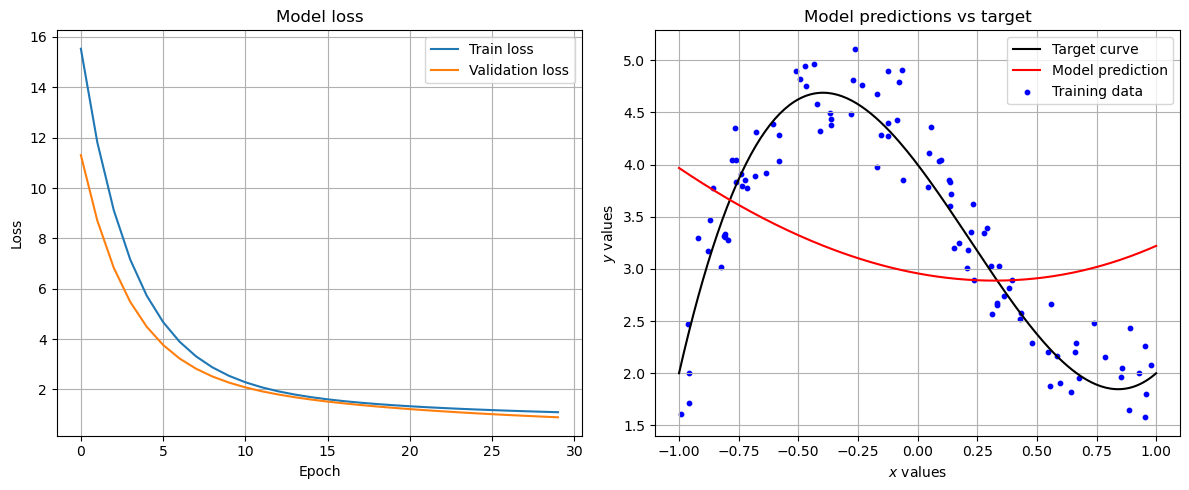

In [26]:
train_and_plot_poly_regression(
    hidden_layers=[], # No hidden layers
    degree=3,
    epochs=30
)

## Observations ##

### Learning Performance ###

The first difference we can observe compared to the previous setting is the rate at which the model's parameters converge to an optimum. Adding more neurons to the input layer makes the neural network to learn faster.

### Predicting Performance ###

Although not yet ideal, we can immidiatly see an improvement compared to what the single perceptron was able to predict.

### Model Setting 2: simple deep neural network ###
-------------

For the sake of the exercise we are supposing we do not know the formula for the target curve ahead. Instead, we are taking an educated guess and suppose a good fit for this data would be a polynomial of degree 3.

To better capture the underlying structure of the input data we set the size of the input layer to 4 neurons. In this setting, each neuron represent a "feature" or "dimension" of the input data as $[x^0, x^1, x^2, x^3]$.

Following the same logic, the output layer should have a single neuron, to represent the single $y$-value of the output. The size of the hidden layer is somewhat arbitrary at this stage, and it could be interesting to twich it later to see the results. For now, we will not have a hidden layer. The rest of the hyperparameters (optimizer, loss function, etc.) are left as before. 

| Layer Type   | Number of Neurons | Activation |
|-------------|-----------------|--------------|
| Input Layer | 4             | Linear       |
| Hidden Layer | 8             | Linear      |
| Output Layer| 1              | Linear       |

- Optimizer: Stochastic Gradient Descent
- Loss function: Mean Squared Error
- Epochs: 30
- Batch size: 32

Validation loss: [0.10418592393398285, 0.10418592393398285]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


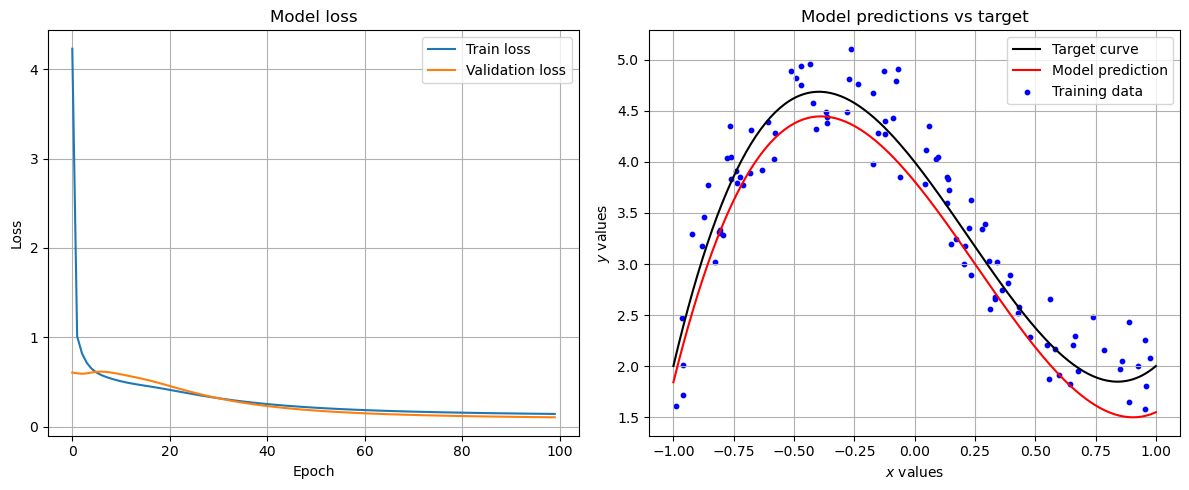

In [27]:
train_and_plot_poly_regression(
    hidden_layers=[16,120,64,32,16], # One hidden layer with 8 neurons
    degree=3,
    epochs=100
)

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

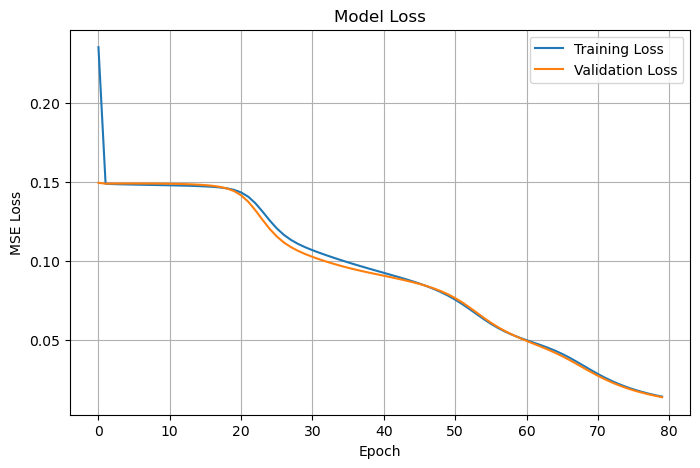

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step


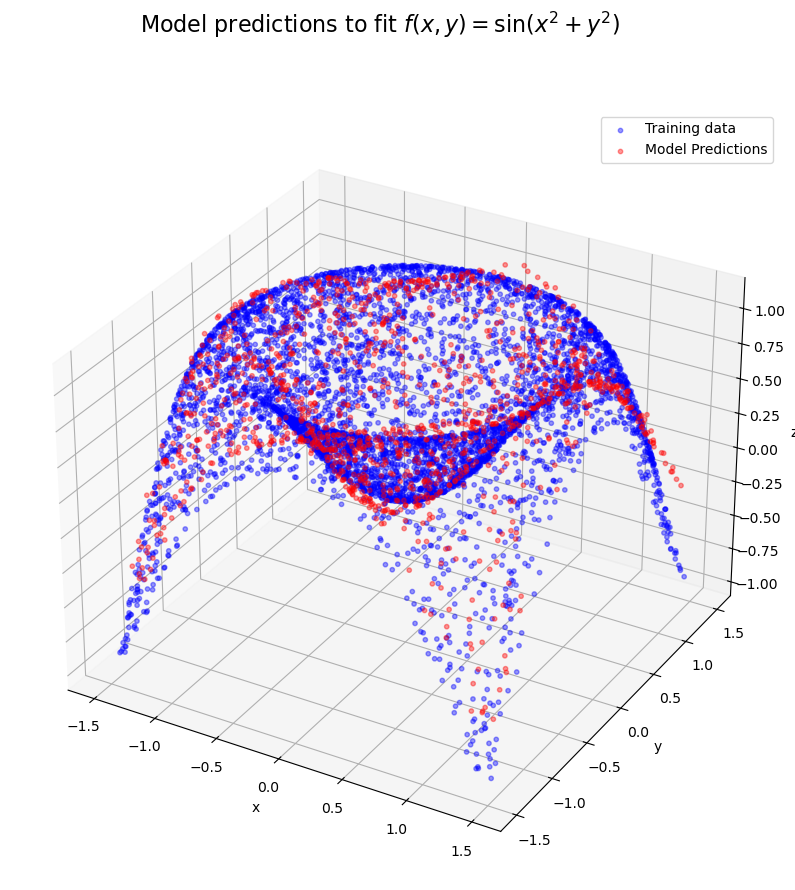

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.initializers import GlorotUniform

# Generate training and test data
np.random.seed(0)
N_train = 5000
N_test = 1250

# Training data
x_train = np.random.uniform(-1.5, 1.5, (N_train, 1))
y_train_ = np.random.uniform(-1.5, 1.5, (N_train, 1))
X_train = np.hstack([x_train, y_train_])
z_train = np.sin(x_train**2 + y_train_**2)

# Test data
x_test = np.random.uniform(-1.5, 1.5, (N_test, 1))
y_test = np.random.uniform(-1.5, 1.5, (N_test, 1))
X_test = np.hstack([x_test, y_test])
z_test_true = np.sin(x_test**2 + y_test**2)


# Build the model
model3 = Sequential([
    Input(shape=(2,)),
    Dense(32, activation='tanh', kernel_initializer=GlorotUniform(seed=0)),
    Dense(32, activation='tanh'),
    Dense(1, activation='linear')
])

model3.compile(optimizer='adam', loss='mse')

# Train the model and keep history
history = model3.fit(X_train, z_train, epochs=80, batch_size=64, verbose=0, validation_split=0.1)

# Plot cost evolution
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model Loss')
plt.grid(True)
plt.legend()
plt.show()

# 3D scatter plot of training and predictions
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
plt.suptitle(r"Model predictions to fit $f(x,y)=\sin(x^2+y^2)$", fontsize=16)

# Training points
ax.scatter3D(
    X_train[:,0], X_train[:,1], z_train.flatten(),
    color='blue', alpha=0.4, s=10, label='Training data'
)

# Predicted points
z_pred = model3.predict(X_test)
ax.scatter3D(
    X_test[:,0], X_test[:,1], z_pred.flatten(),
    color='red', alpha=0.4, s=10, label='Model Predictions'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
plt.show()

Ideas to meditate on these exercises and judge your results can be found <a href=https://xkcd.com/2048/>here</a>

### <span style="color:green">Supplementary material: Keras model.fit available callbacks</span>

The .fit method can also get <a href=https://keras.io/callbacks/>callback</a> functions which can be used to customize the fitting procedure with special actions.

Keras provides some predefined callbacks to feed in, among them for example:
- **TerminateOnNaN()**: that terminates training when a NaN loss is encountered
- **ModelCheckpoint(filepath)**: that save the model after every epoch
- **EarlyStopping()**: which stop training when a monitored quantity has stopped improving

You can select one or more callback and pass them as a list to the callback argument of the fit method.

Now we are going to construct a callback object to represent how estimated parameters are converging during the training procedure

We will use also an EarlyStopping callback on the val_loss quantity. This will stop the training process as soon as the val_loss quantity does not improve anymore after an amount of epochs, preventing a long time of wated computation to take over without useful results.

<code>keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=0, verbose=0, mode='auto', baseline=None, restore_best_weights=False)</code>

Arguments:

- <code>monitor</code>: quantity to be monitored. 
- <code>min_delta:</code> minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute change of less than min_delta, will count as no improvement. 
- <code>patience:</code> number of epochs with no improvement after which training will be stopped. 
- <code>verbose:</code> verbosity mode. 
- <code>mode:</code> one of {auto, min, max}. In min mode, training will stop when the quantity monitored has stopped decreasing; in max mode it will stop when the quantity monitored has stopped increasing; in auto mode, the direction is automatically inferred from the name of the monitored quantity. 
- <code>baseline:</code> Baseline value for the monitored quantity to reach. Training will stop if the model doesn't show improvement over the baseline. 
- <code>restore_best_weights:</code> whether to restore model weights from the epoch with the best value of the monitored quantity. If False, the model weights obtained at the last step of training are used.